## Analysing GridMaze ephys data

This notebook walks through a typical analysis with the dataset, using **spatial tuning** (place coding in mFC) as the worked example. 

In this example we:

1. **Load a session** with the raw streams you need (spikes, tracking, trial info).
2. **Build a frame-aligned DataFrame** that combines behaviour with neuron firing rates (`get_session_df`). One row per tracking frame, one column per behavioural variable and neuron — a convientient data structure for downstream analysis.
3. **Compute a session-level summary**: in our case this will be a df containing the average firing rate of each neuron aross spatial locations (`get_heatmap_df`)
4. **Visualise some single cells** this is always fun & a good way to check things are working.
5. **Aggregate across sessions** by using `get_heatmap_df` over all late (expert) sessions for one subject we can pool heatmaps across sessions for further analysis
6. **Run population methods** on the aggregated data, eg. Non-negative matrix factorisation to visualise low-dimensional common structure across neurons

In [34]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import NMF
from GridMaze.core import get_sessions as gs

### Load a session

`get_maze_sessions` returns a session object, here filtered to a single subject / maze / day. The `with_data` list controls which raw streams get loaded — here, spikes plus the behavioural and trial dataframes.

In [35]:
session = gs.get_maze_sessions(
    subject_IDs=["m6"],
    maze_names=["maze_1"],
    days_on_maze=[13],
    with_data=[
        "spike_times",
        "spike_clusters",
        "cluster_metrics",
        "tracking_df",
        "trajectories_df",
        "trial_info_df",
    ],
)

### Frame-aligned behaviour + firing rates

`get_session_df` returns a DataFrame with one row per tracking frame and columns for behaviour (position, head direction, speed, trial info) plus one firing-rate column per cluster. This is the bedrock data structure for everything downstream.

In [ ]:
def get_session_df(session, single_units_only=True, smooth_SD=None, position_smooth_s=0.1, window_size=1000):
    """One row per tracking frame, columns = behaviour + per-cluster firing rates.

    Inputs: session; single_units_only (keep only single-unit clusters); smooth_SD (firing-rate Gaussian kernel SD, s; defaults to one frame); position_smooth_s (position-smoothing SD, s, applied before computing speed); window_size (frame-chunk size for the firing-rate kernel matrix).
    Output: DataFrame with MultiIndex columns — trajectories_df fields, derived speed (m/s), trial_info_df fields, and one firing_rate column per cluster (named "{session.name}_cluster{ID}").
    """
    traj = session.trajectories_df
    frame_times = traj["time"].to_numpy().ravel()
    frame_rate = round(len(frame_times) / (frame_times[-1] - frame_times[0]))

    # filter clusters
    metrics = session.cluster_metrics
    all_cluster_IDs = metrics["cluster_ID"].to_numpy().ravel()
    if single_units_only:
        keep = metrics["single_unit"].to_numpy().ravel().astype(bool)
        cluster_IDs = np.sort(all_cluster_IDs[keep])
    else:
        cluster_IDs = np.sort(np.unique(session.spike_clusters))

    # firing rates
    spike_times = np.asarray(session.spike_times).reshape(-1)
    spike_clusters = np.asarray(session.spike_clusters).reshape(-1)
    if smooth_SD is None:
        smooth_SD = 1 / frame_rate
    rates = np.zeros((len(cluster_IDs), len(frame_times)))
    for i, cluster_ID in enumerate(cluster_IDs):
        cluster_spike_times = spike_times[spike_clusters == cluster_ID]
        for start in range(0, len(frame_times), window_size):
            end = min(start + window_size, len(frame_times))
            t_window = frame_times[start:end]
            spikes_in_window = cluster_spike_times[
                (cluster_spike_times >= frame_times[start]) & (cluster_spike_times <= frame_times[end - 1])
            ]
            kernel = norm.pdf(t_window[:, None] - spikes_in_window, scale=smooth_SD)
            rates[i, start:end] = kernel.sum(axis=1)

    # speed from gaussian-smoothed centroid
    x = traj[("centroid_position", "x")].to_numpy()
    y = traj[("centroid_position", "y")].to_numpy()
    sigma = position_smooth_s * frame_rate
    x_s = gaussian_filter1d(x, sigma)
    y_s = gaussian_filter1d(y, sigma)
    speed = np.sqrt(np.gradient(x_s) ** 2 + np.gradient(y_s) ** 2) * frame_rate

    # assemble (preserves the trajectories MultiIndex column convention)
    speed_df = pd.DataFrame(
        speed,
        index=traj.index,
        columns=pd.MultiIndex.from_tuples([("speed", "")]),
    )
    ti = session.trial_info_df.copy()
    ti.columns = pd.MultiIndex.from_tuples([(c, "") for c in ti.columns])
    cluster_labels = [f"{session.name}_cluster{int(cid)}" for cid in cluster_IDs]
    fr_df = pd.DataFrame(
        rates.T,
        index=traj.index,
        columns=pd.MultiIndex.from_product([["firing_rate"], cluster_labels]),
    )
    return pd.concat([traj, speed_df, ti, fr_df], axis=1)


session_df = get_session_df(session)
session_df.head()

time head_direction              centroid_position            \
                     value interpolated                 x         y   
0 -7.700358      24.726455            0          1.249763  1.210644   
1 -7.683691      34.846706            0          1.251581  1.209989   
2 -7.667023      34.537304            0          1.254180  1.212556   
3 -7.650356      36.067532            1          1.240161  1.200748   
4 -7.633688      40.215607            0          1.251867  1.212444   

               maze_position              speed trial  ...  \
  interpolated        simple skeleton                  ...   
0            0            G7    G7_SE  0.006381   NaN  ...   
1            0            G7    G7_SE  0.009466   NaN  ...   
2            0            G7    G7_SE  0.015439   NaN  ...   
3            0            G7  G6-G7_N  0.020952   NaN  ...   
4            0            G7    G7_SE  0.025899   NaN  ...   

                    firing_rate                                \
  m6.2022-07-05.maze_cluster112 m6.2022-07-05.maze_cluster114   
0                           0.0                 1.321812e-303   
1                           0.0                 1.449762e-287   
2                           0.0                 5.849100e-272   
3                           0.0                 8.680533e-257   
4                           0.0                 4.738806e-242   

                                                               \
  m6.2022-07-05.maze_cluster116 m6.2022-07-05.maze_cluster123   
0                           0.0                 1.609438e-135   
1                           0.0                 7.337933e-125   
2                           0.0                 1.230661e-114   
3                           0.0                 7.592211e-105   
4                           0.0                  1.722912e-95   

                                                               \
  m6.2022-07-05.maze_cluster126 m6.2022-07-05.maze_cluster127   
0                      1.160282                  2.869965e-25   
1                     10.048583                  9.680816e-21   
2                     33.967292                  1.201192e-16   
3                     45.353497                  5.482491e-13   
4                     23.998519                  9.204678e-10   

                                                               \
  m6.2022-07-05.maze_cluster130 m6.2022-07-05.maze_cluster134   
0                           0.0                           0.0   
1                           0.0                           0.0   
2                           0.0                           0.0   
3                           0.0                           0.0   
4                           0.0                           0.0   

                                                               
  m6.2022-07-05.maze_cluster135 m6.2022-07-05.maze_cluster141  
0                           0.0                      0.866716  
1                           0.0                      7.026892  
2                           0.0                     22.265999  
3                           0.0                     33.522062  
4                           0.0                     36.686776  

[5 rows x 77 columns]

### Per-location firing-rate summary

`get_heatmap_df` filters the frame-aligned DataFrame to navigation epochs above a speed threshold, groups by simple-maze location, and returns each cell's mean firing rate at each location. Low-occupancy locations are dropped and re-inserted as NaN so they're flagged downstream rather than silently noisy.

In [37]:
def get_heatmap_df(session, navigation_only=True, single_units_only=False, speed_threshold=0.05, min_occupancy=1):
    """Per-location mean firing rate for each cell in a session.

    Inputs: session; navigation_only (restrict to navigation epochs); single_units_only (keep only single-unit clusters); speed_threshold (drop frames slower than this, m/s); min_occupancy (drop locations visited for less than this, s).
    Output: DataFrame indexed by maze-location label, one column per cluster; locations missing or below min_occupancy are NaN.
    """
    session_df = get_session_df(session, single_units_only=single_units_only)

    # filter by trial phase and speed
    _df = session_df.copy()
    if navigation_only:
        _df = _df[_df[("trial_phase", "")] == "navigation"]
    if speed_threshold is not None:
        _df = _df[_df[("speed", "")] >= speed_threshold]

    # filter by minimum occupancy (seconds -> frames)
    if min_occupancy is not None:
        times = session_df[("time", "")].to_numpy()
        frame_rate = round(len(times) / (times[-1] - times[0]))
        min_frames = min_occupancy * frame_rate
        occupancy = _df.groupby([("maze_position", "simple")]).size()
        valid_positions = occupancy[occupancy >= min_frames].index
        _df = _df[_df[("maze_position", "simple")].isin(valid_positions)]

    # locations present in the maze but missing from the filtered data
    simple_maze = session.simple_maze()
    all_locations = list(nx.get_node_attributes(simple_maze, "label").values()) + list(
        nx.get_edge_attributes(simple_maze, "label").values()
    )
    missing_locations = sorted(set(all_locations) - set(_df[("maze_position", "simple")].unique()))

    # mean firing rate per location, NaN for missing locations
    heatmap_df = _df.groupby([("maze_position", "simple")]).firing_rate.mean().firing_rate
    if missing_locations:
        missing_df = pd.DataFrame(
            np.nan,
            index=missing_locations,
            columns=heatmap_df.columns,
        )
        heatmap_df = pd.concat([heatmap_df, missing_df], axis=0)
    return heatmap_df.sort_index()


heatmap_df = get_heatmap_df(session)
heatmap_df.head()

,m6.2022-07-05.maze_cluster0,m6.2022-07-05.maze_cluster1,m6.2022-07-05.maze_cluster2,m6.2022-07-05.maze_cluster3,m6.2022-07-05.maze_cluster4,m6.2022-07-05.maze_cluster5,m6.2022-07-05.maze_cluster6,m6.2022-07-05.maze_cluster7,m6.2022-07-05.maze_cluster8,m6.2022-07-05.maze_cluster9,...,m6.2022-07-05.maze_cluster132,m6.2022-07-05.maze_cluster133,m6.2022-07-05.maze_cluster134,m6.2022-07-05.maze_cluster135,m6.2022-07-05.maze_cluster136,m6.2022-07-05.maze_cluster137,m6.2022-07-05.maze_cluster138,m6.2022-07-05.maze_cluster139,m6.2022-07-05.maze_cluster140,m6.2022-07-05.maze_cluster141
A1,6.441674,8.287864,7.932921,13.944788,24.048501,3.485703,0.147754,4.365834,1.731516,0.530241,...,7.915961,18.826608,1.912047e-19,2.628668e-01,17.143155,6.908422,8.188630e-229,9.446307,4.702988,33.523081
A1-A2,8.673142,12.101826,4.632069,16.624140,19.188489,5.327116,0.949203,8.994938,6.589664,6.131918,...,15.648739,12.500833,0.000000e+00,3.394732e-01,5.494538,4.870503,7.814951e-02,9.690840,6.067189,47.645847
A2,13.576646,14.198597,7.778569,20.620303,27.290210,9.220060,3.995462,16.275298,12.247295,9.889339,...,17.209968,16.168418,0.000000e+00,2.340794e-01,7.377148,5.864026,1.089926e-55,14.128929,7.311048,53.454810
A2-B2,11.315479,16.193203,6.923758,24.224776,27.150653,2.633603,1.839471,3.177837,2.920674,2.878899,...,10.829779,15.161348,0.000000e+00,4.931963e-01,4.400757,4.719641,0.000000e+00,8.880829,2.782438,34.339561
A3,5.419068,12.920115,2.692576,16.696238,38.636499,4.925887,7.850694,13.014285,12.454230,1.859943,...,3.306292,15.693659,8.320848e-42,1.401496e-13,2.371181,4.422540,1.428036e-01,9.976452,4.823444,34.537759


### Visualise a single cell

`plot_maze_heatmap` draws a per-location value (here a single cell's spatial tuning) on the simple maze graph — nodes are corridor junctions, edges are corridor segments. NaN locations render grey.

<Axes: >

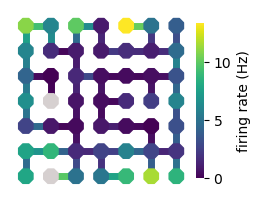

In [38]:
def plot_maze_heatmap(simple_maze, place_values, ax=None, cmap="viridis", label="firing rate (Hz)", cmap_style="abrev"):
    """Heatmap of per-location values drawn on the simple-maze graph (NaN locations render grey).

    Inputs: simple_maze; place_values (Series indexed by location label, e.g. "A1" or "A1-A2"); ax (matplotlib axis, optional); cmap (colormap name); label (colorbar label); cmap_style ("full" = colorbar to the right, "abrev" = peak value as text in the top-right corner).
    Output: the matplotlib axis.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(2.5, 2.5))

    node_label = nx.get_node_attributes(simple_maze, "label")
    edge_label = nx.get_edge_attributes(simple_maze, "label")
    node_values = np.array([place_values.get(node_label[n], np.nan) for n in simple_maze.nodes], dtype=float)
    edge_values = np.array([place_values.get(edge_label[e], np.nan) for e in simple_maze.edges], dtype=float)

    cmap = plt.get_cmap(cmap).with_extremes(bad="#d6d0d0")
    vmax = float(np.nanmax(place_values))
    norm = plt.Normalize(vmin=0, vmax=vmax)

    node_colors = cmap(norm(node_values))
    edge_colors = cmap(norm(edge_values))

    nx.draw_networkx(
        simple_maze,
        pos=nx.get_node_attributes(simple_maze, "position"),
        ax=ax,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=125,
        node_shape="8",
        width=5,
        with_labels=False,
    )
    ax.set_aspect("equal")
    ax.axis("off")

    if cmap_style == "full":
        cbar = plt.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=cmap),
            ax=ax,
            fraction=0.04,
            pad=0.02,
        )
        cbar.outline.set_visible(False)
        cbar.set_label(label)
    elif cmap_style == "abrev":
        ax.text(0.95, 1.05, f"{vmax:.0f} Hz", transform=ax.transAxes, ha="right", va="top", fontsize=10)

    return ax


simple_maze = session.simple_maze()
example_cell = "m6.2022-07-05.maze_cluster2"
plot_maze_heatmap(simple_maze, heatmap_df[example_cell], cmap_style="full")

A quick 8×8 grid of the first 64 single-unit spatial tuning maps — useful for eyeballing which cells look spatially tuned and which don't.

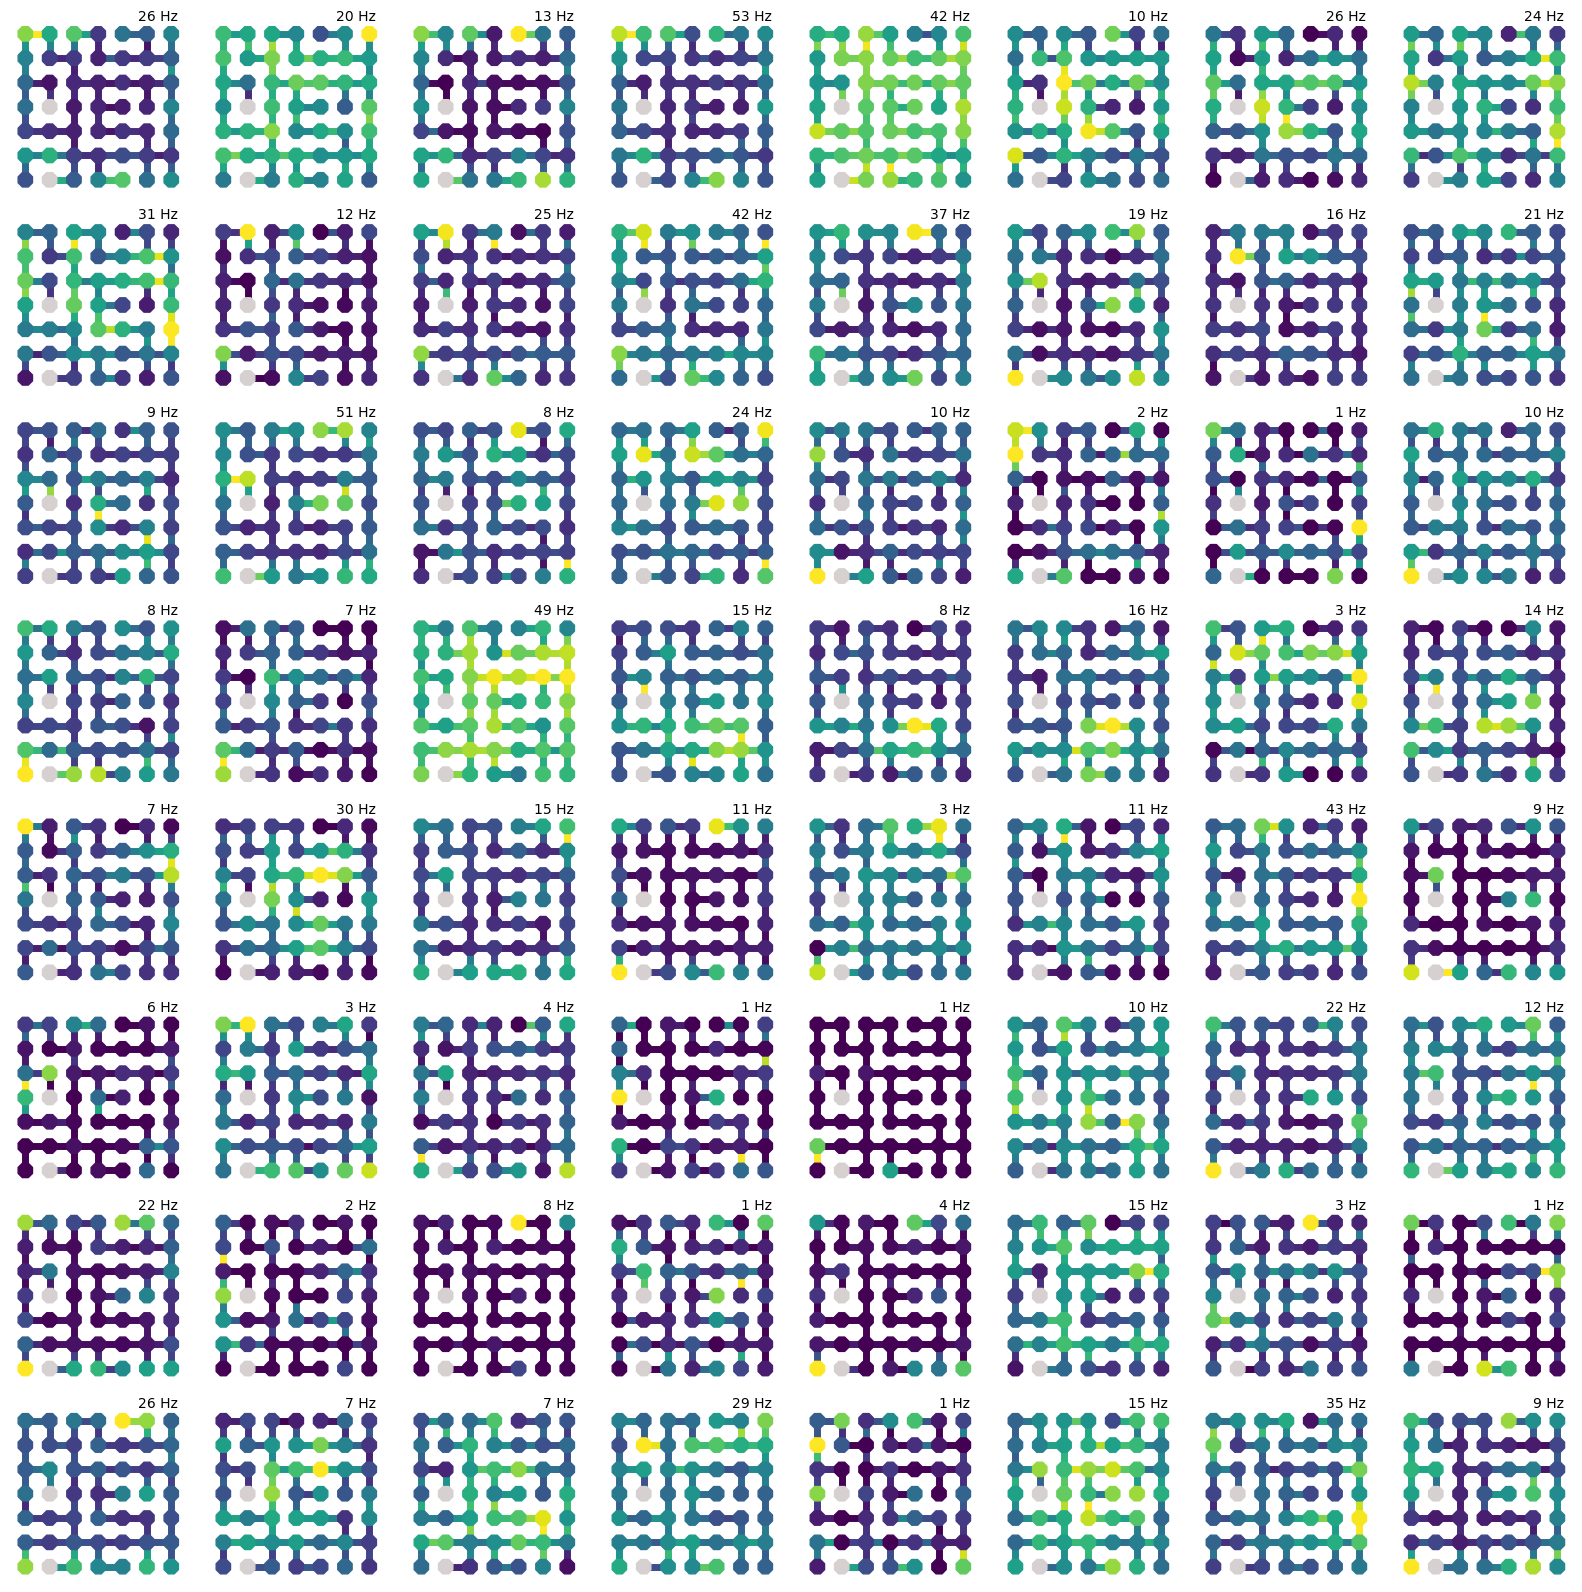

In [39]:
fig, axes = plt.subplots(8, 8, figsize=(16, 16))
for ax, cluster in zip(axes.flat, heatmap_df.columns[:64]):
    plot_maze_heatmap(simple_maze, heatmap_df[cluster], ax=ax, cmap_style="abrev")
fig.tight_layout()

## Aggregating across sessions

Some of this spatial tuning looks interesting. We can also combine data across sessions and do population level analyses.

In [40]:
sessions = gs.get_maze_sessions(
    subject_IDs=["m6"],
    maze_names=["maze_1"],
    days_on_maze="late",
    with_data=[
        "spike_times",
        "spike_clusters",
        "cluster_metrics",
        "tracking_df",
        "trajectories_df",
        "trial_info_df",
    ],
)

For each session, compute the per-location heatmap and concatenate along columns to get a single `(locations × cells)` matrix. The row index aligns automatically because every session shares the same maze.

In [ ]:
big_heatmap_df = pd.concat([get_heatmap_df(s, single_units_only=True) for s in sessions], axis=1)

## Population analysis: low-dimensional spatial basis

With the `(locations × cells)` matrix in hand, dimensionality reduction surfaces recurring spatial patterns across the population. NMF here gives a non-negative spatial basis — each component can be visualised as heatmap, NMF is nice because it is non-negative by construction so the output components are easy to visualise.

In [ ]:
def get_nmf_df(big_heatmap_df, normalise=True, n_components=10, random_state=0):
    """NMF decomposition of a (locations x cells) firing-rate matrix into spatial components.

    Inputs: big_heatmap_df (rows = maze locations, columns = cells across sessions; NaN entries are imputed with each cell's mean); normalise (rescale each cell to unit L2 norm so high- and low-firing cells weigh equally); n_components; random_state.
    Output: DataFrame with the same row index as `big_heatmap_df` and one column per component; locations never visited across the whole dataset are NaN.
    """
    X = big_heatmap_df.fillna(big_heatmap_df.mean()).to_numpy().T  # (n_cells, n_locations)
    if normalise:
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        X = np.divide(X, norms, where=norms > 0)

    nmf = NMF(n_components=n_components, init="nndsvd", max_iter=1000, random_state=random_state)
    nmf.fit(X)

    nmf_df = pd.DataFrame(
        nmf.components_.T,
        index=big_heatmap_df.index,
        columns=[f"component_{i}" for i in range(n_components)],
    )

    # never-visited locations -> NaN (renders grey when plotted)
    never_visited = big_heatmap_df.isna().all(axis=1)
    nmf_df.loc[never_visited] = np.nan
    return nmf_df


nmf_df = get_nmf_df(big_heatmap_df)
nmf_df.head()

,component_0,component_1,component_2,component_3,component_4,component_5,component_6,component_7,component_8,component_9
A1,0.031661,1.186781,0.000000,0.000000,0.005030,0.000000,0.261351,0.000000,0.000000,0.045520
A1-A2,0.000000,0.576130,0.655339,0.103630,0.000000,0.004847,0.000000,0.087785,0.000000,0.000000
A2,0.145327,0.047983,0.185082,0.000000,0.135974,0.000000,0.544288,0.055897,0.137503,0.136667
A2-B2,0.139446,0.000000,0.526226,0.000000,0.364803,0.000000,0.019745,0.046717,0.009366,0.086676
A3,0.226600,0.166507,0.074669,0.145226,0.000000,0.163615,0.138741,0.098935,0.085217,0.097701


Plot each of the 10 NMF components as a spatial heatmap to see what recurring spatial patterns the decomposition picked up across the population.

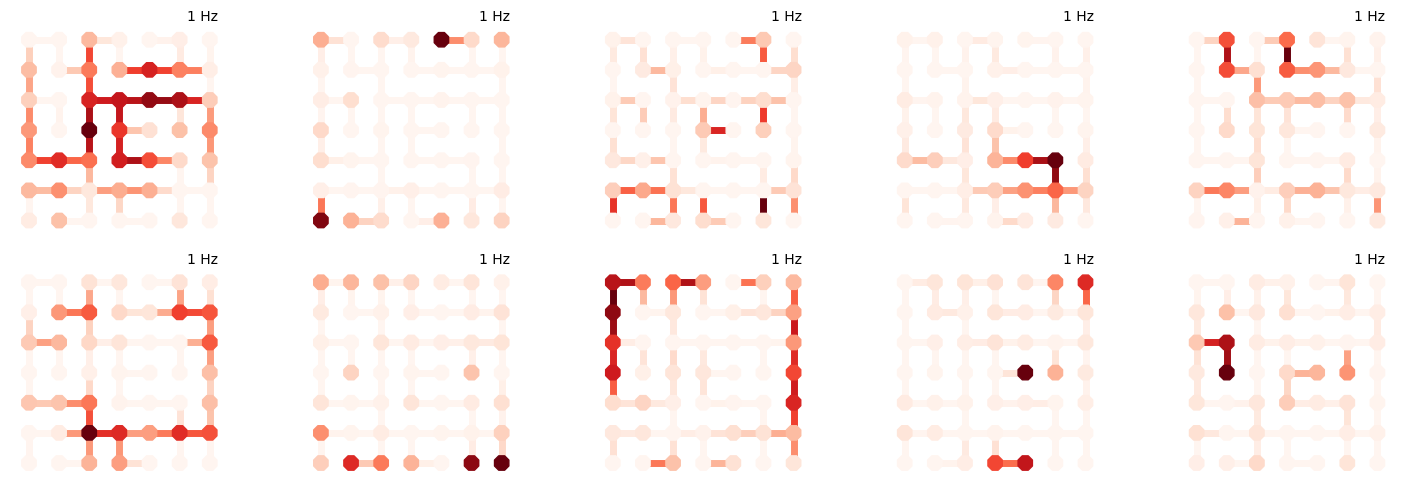

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for ax, component in zip(axes.flat, nmf_df.columns):
    plot_maze_heatmap(simple_maze, nmf_df[component], ax=ax, cmap="Reds", cmap_style="abrev")
fig.tight_layout()